In [ ]:
#Selektivne reportovanie nezavislych premennych

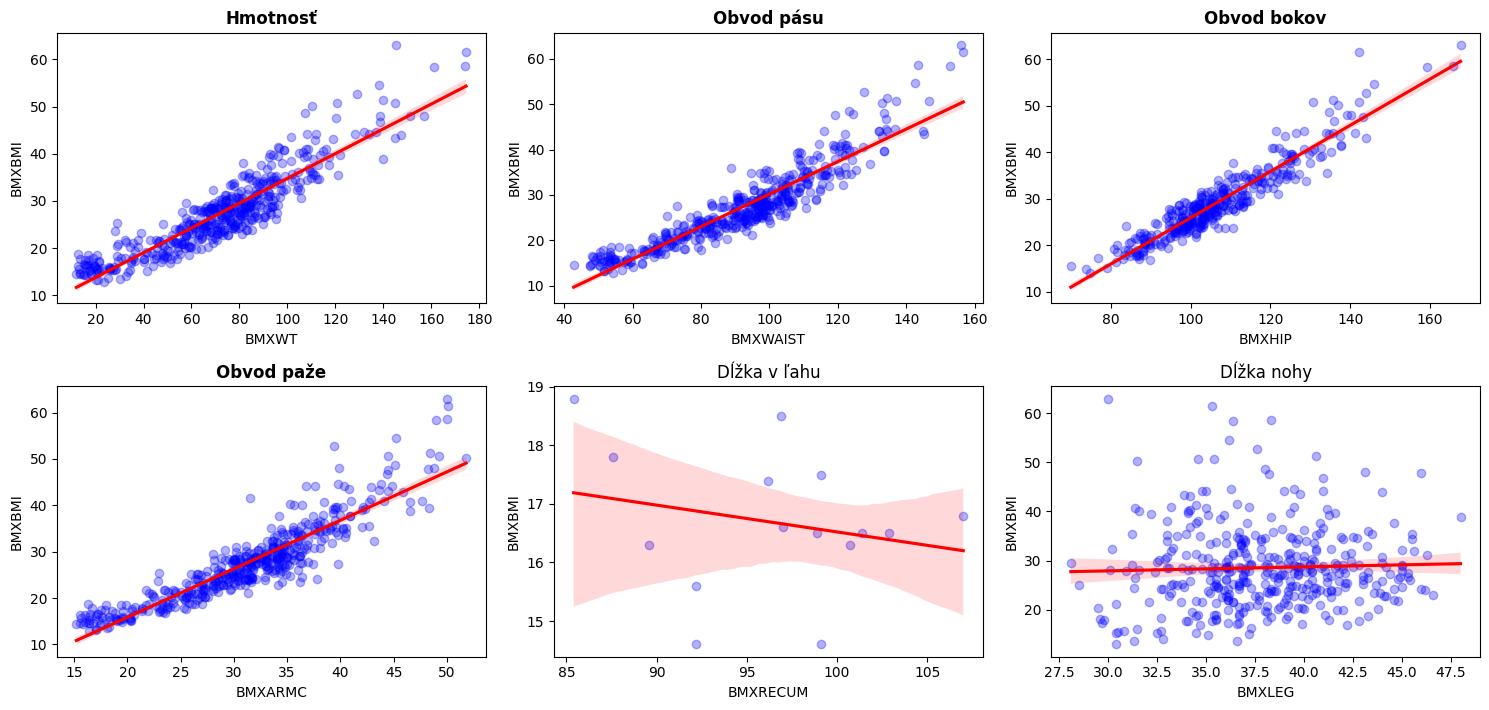

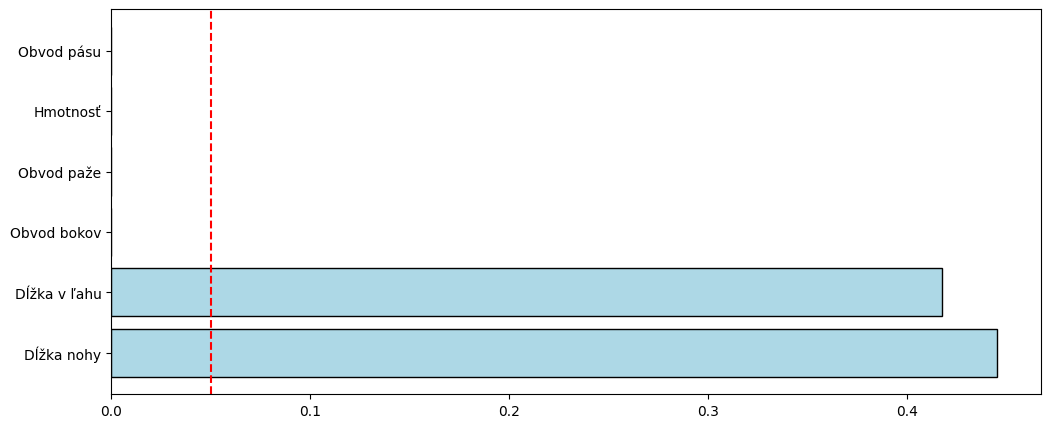

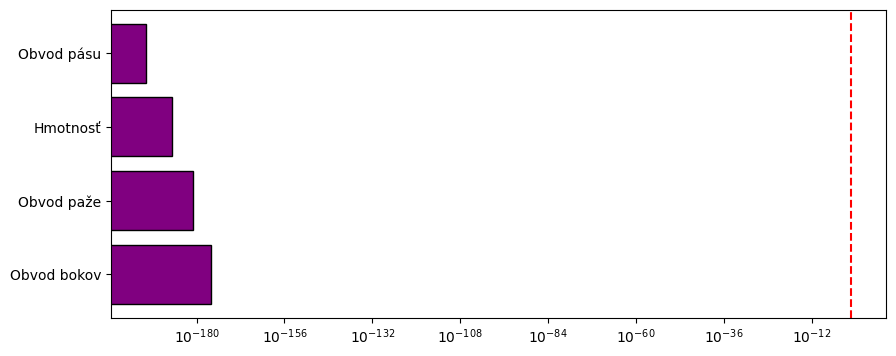

Signifikantné vysledky:
    Faktor (X)      p-hodnota  Signifikantné
2  Obvod bokov  9.873699e-177           True
3   Obvod paže  1.321126e-181           True
0     Hmotnosť  1.914055e-187           True
1   Obvod pásu  2.044981e-194           True
Vsetky vysledky:
  Faktor (X)     p-hodnota  Signifikantné
  Obvod pásu 2.044981e-194           True
    Hmotnosť 1.914055e-187           True
  Obvod paže 1.321126e-181           True
 Obvod bokov 9.873699e-177           True
Dĺžka v ľahu  4.173635e-01          False
  Dĺžka nohy  4.451950e-01          False


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import warnings
import sys
import os

sys.path.append(os.path.abspath(".."))
import settings


def load_file(file_path):
    return pd.read_sas(file_path, format='xport')


# načítanie dát (používame len BMX)
bmx = load_file(settings.bmx_path)
data = bmx

# Ignorovanie warningov
warnings.filterwarnings("ignore")


# simulacia
def analyze_p_hacking(data):
    # závislá premenná
    target_y = 'BMXBMI'

    # nezávislé premenné
    predictors = { 'BMXWT': 'Hmotnosť',
                  'BMXWAIST': 'Obvod pásu', 
                  'BMXHIP': 'Obvod bokov', 
                  'BMXARMC': 'Obvod paže', 
                  'BMXHEAD' : 'Obvod hlavy',
                  'BMXRECUM' : 'Dĺžka v ľahu', 
                  'BMXLEG' : 'Dĺžka nohy' }

    sample = data.sample(n=500, random_state=42)
    results = []
    
    # grafy regresií
    plt.figure(figsize=(15, 8))
    plot_idx = 1

    for code, name in predictors.items():
        if code not in sample.columns:
            continue
        
        # očistenie dát
        df_sub = sample[[target_y, code]].dropna()

        # vyber nezavislej premennej
        X = sm.add_constant(df_sub[code])
        # sledovana premenna
        y = df_sub[target_y]
        
        try:
            #linearna regresia
            model = sm.OLS(y, X).fit()
            p_val = model.pvalues[code]
            
            results.append({
                "Faktor (X)": name,
                "p-hodnota": p_val,
                "Signifikantné": p_val < 0.05
            })

            # vykreslenie grafu
            if plot_idx <= 6:
                plt.subplot(2, 3, plot_idx)
                sns.regplot(
                    x=code,
                    y=target_y,
                    data=df_sub,
                    scatter_kws={'alpha': 0.3, 'color': 'blue'},
                    line_kws={'color': 'red'}
                )
                plt.title(
                    name,
                    fontweight='bold' if p_val < 0.05 else 'normal'
                )
                plot_idx += 1

        except:
            continue
        
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig("ols_grafy.png", dpi=300)
    plt.show()
    
    return pd.DataFrame(results)


# spustenie analýzy
df_results = analyze_p_hacking(data)


# graf - kompletny prehlad
plt.figure(figsize=(12, 5))
df_plot_full = df_results.sort_values('p-hodnota', ascending=False)

colors = ['pink' if s else 'lightblue' for s in df_plot_full['Signifikantné']]

plt.barh(
    df_plot_full['Faktor (X)'],
    df_plot_full['p-hodnota'],
    color=colors,
    edgecolor='black'
)
plt.axvline(0.05, color='red', linestyle='--')
plt.savefig("all_results", dpi=300, bbox_inches='tight')
plt.show()


# graf selektivny report
plt.figure(figsize=(10, 4))
df_significant = df_results[df_results['Signifikantné'] == True]
df_significant = df_significant.sort_values('p-hodnota', ascending=False)

plt.barh(
    df_significant['Faktor (X)'],
    df_significant['p-hodnota'],
    color='purple',
    edgecolor='black'
)
plt.axvline(0.05, color='red', linestyle='--')
plt.xscale('log') 
plt.savefig("selective_report", dpi=300, bbox_inches='tight')
plt.show()

print('Signifikantné vysledky:')
print(df_significant)


df_significant.to_csv("significant_results.csv", index=False)

print('Vsetky vysledky:')
df_all = df_results.sort_values('p-hodnota')

print(df_all.to_string(index=False))
df_all.to_csv("all_results.csv", index=False, encoding="utf-8")

Pre každú z testovaných nezávislých premenných bola stanovená nulová hypotéza ($H_0$), ktorá predpokladá, že daný faktor neovplyvňuje ekonomický status domácnosti (INDFMPIR), a teda príslušný regresný koeficient je nulový. Alternatívna hypotéza ($H_1$) predpokladá existenciu štatisticky významného vzťahu. Hladina významnosti bola stanovená na $\alpha = 0,05$. Selektívne reportovanie v tejto práci demonštruje tendenciu publikovať iba tie výsledky, pri ktorých došlo k zamietnutiu $H_0$.